# Analysis of the Relationship Between Product Categories and Sales Effectiveness (Inner)

## Member: Phuong

### Bàn luận:
Dựa trên phần EDA, ta có thể thấy có 5 root mỗi root chứa nhiều middle, mỗi middle chứa nhiều leaf
Vì vậy có rất nhiều thứ cần phải phân tích trong một danh mục.
Để đảm bảo insight được khách quan và thực sự cung cấp thông tin hữu ích cho người đọc. Em sẽ tiếp cận bằng một mục tiêu phân tích bao quát nhất

### Analysis Objectives:
1. **Question 1**: Với từng root danh mục, danh mục con trực tiếp nào đang phát triển mạnh nhất (doanh thu, số danh mục con, tổng sản phẩm)?
2. **Question 2**: Khám phá chuyên sâu những danh mục phát triển mạnh nhất đó xem yếu tố nào chính là yếu tố ảnh hưởng lớn nhất (Dùng linear để predict doanh thu xem cái nào có trọng số cao nhất)?
attributes: trong bảng product
target: price * sold_count


!!! - Chấp nhận rằng linear chỉ cho bạn insight tuyến tính, không phải là “chân lý” nhân quả.

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter, FixedLocator
from IPython.display import display

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler


import os
import warnings
warnings.filterwarnings('ignore')

# Display configuration
plt.rcParams['figure.figsize'] = (16, 10)
plt.rcParams['font.size'] = 10
plt.rcParams['font.family'] = 'sans-serif'
sns.set_style('whitegrid')
sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)


# Create output directory if not exists
output_dir = '../output'
os.makedirs(output_dir, exist_ok=True)

## 1. Load Common Data

In [3]:
# Load 4 common data tables following team standards
df_store = pd.read_csv('../data/stores.csv')
df_category = pd.read_csv('../data/categories.csv')
df_product = pd.read_csv('../data/products.csv')
df_review = pd.read_csv('../data/reviews.csv')

print("Data Size:")
print(f"Stores: {df_store.shape}")
print(f"Categories: {df_category.shape}")
print(f"Products: {df_product.shape}")
print(f"Reviews: {df_review.shape}")

Data Size:
Stores: (1446, 5)
Categories: (496, 4)
Products: (55883, 14)
Reviews: (158126, 9)


## 2. Category Exploration
- Khám phá các root category (trỏng có bao nhiêu nhánh)
- EDA cơ bản về dữ liệu từng category (doanh thu tổng, chart danh thu cho từng category)
- ...

In [4]:
sns.set_theme(style="whitegrid")
main_cmap = sns.color_palette("mako", as_cmap=True)

In [5]:
# parent_dict = dict(zip(df_category['category_name'], df_category['parent_category'])) 
# root_categories = [
#     "diengiadung", 
#     "dienthoai_maytinhbang", 
#     "dientu_dienlanh", 
#     "laptop_mayvitinh_linhkien", 
#     "thietbiso_phukienso"
# ]

# for root in root_categories:
#     df_category.loc[df_category['category_name'] == root, 'root_category'] = root
# cat_to_root_dict = dict(zip(df_category['category_id'], df_category['root_category']))
# df_product_eda = df_product.copy()
# df_product_eda['category_id'] = df_product_eda['category_id'].astype(str)
# df_product_eda['root_category'] = df_product_eda['category_id'].map(cat_to_root_dict)
# df_product_eda['price'] = pd.to_numeric(df_product_eda['price'], errors='coerce').fillna(0)
# df_product_eda['sold_count'] = pd.to_numeric(df_product_eda['sold_count'], errors='coerce').fillna(0)
# df_product_eda['revenue'] = df_product_eda['price'] * df_product_eda['sold_count']

# # --- CẤU HÌNH STYLE ĐỒNG NHẤT ---
# plt.rcParams['font.family'] = 'sans-serif'
# sns.set_theme(style="white", palette="crest") # Sử dụng crest xuyên suốt
# MAIN_COLOR = "#234d51" # Màu chủ đạo lấy từ palette crest

# fig = plt.figure(figsize=(18, 14))
# # Tăng chiều cao cho hàng 1 để Donut chart có không gian
# gs = fig.add_gridspec(
#     2, 2,
#     height_ratios=[1, 1.2],  # boxplot lớn hơn
#     width_ratios=[1, 1],     # cân 2 bên
#     hspace=0.25,
#     wspace=0.15              # thêm khoảng cách ngang
# )

# def format_money(x, pos):
#     if x >= 1_000_000_000: return f'{x / 1_000_000_000:,.1f}B'
#     if x >= 1_000_000: return f'{x / 1_000_000:,.0f}M'
#     return f'{x:,.0f}'

# # --- AX1: BAR CHART (Đồng bộ màu) ---
# ax1 = fig.add_subplot(gs[0, 0])
# sub_cat_count = df_category[df_category['parent_category'] != ''].groupby('root_category')['category_id'].count().sort_values(ascending=False)
    
# sns.barplot(x=sub_cat_count.values, y=sub_cat_count.index, palette="mako", ax=ax1)
# ax1.set_title('1. CẤU TRỤC DANH MỤC\n(Số lượng danh mục con)', loc='left', fontweight='bold', pad=15)
# ax1.set_xlabel('Số lượng danh mục nhánh')
# ax1.set_ylabel('')

# for i, v in enumerate(sub_cat_count.values):
#     ax1.text(v + 0.5, i, f' {int(v)}', va='center', fontweight='bold', color=MAIN_COLOR)
# sns.despine(ax=ax1, left=True, bottom=True)

# # --- AX2: DONUT CHART (Phóng to & Cân đối) ---
# ax2 = fig.add_subplot(gs[0, 1])
# revenue_by_root = df_product_eda.groupby('root_category')['revenue'].sum().sort_values(ascending=False)
# revenue_by_root = revenue_by_root[revenue_by_root > 0]

# # Tăng size bằng cách điều chỉnh radius
# wedges, texts, autotexts = ax2.pie(
#     revenue_by_root.values, 
#     autopct='%1.1f%%',
#     startangle=140, 
#     pctdistance=0.75,
#     radius=1.1, # Phóng to donut
#     colors=sns.color_palette("viridis", len(revenue_by_root)),
#     wedgeprops={'width': 0.45, 'edgecolor': 'w', 'linewidth': 2}
# )

# ax2.legend(
#     wedges, revenue_by_root.index,
#     title="Danh mục",
#     loc="center left",
#     bbox_to_anchor=(1.05, 0.5),  # đặt bên phải
#     frameon=False
# )

# plt.setp(autotexts, size=10, weight="bold", color="white")
# ax2.set_title(
#     '2. CƠ CẤU DOANH THU\n(% Đóng góp)',
#     loc='left',
#     fontweight='bold',
#     pad=15  # giảm pad cho cân
# )
# # --- AX3: BOXPLOT (Fix Median Log Scale) ---
# ax3 = fig.add_subplot(gs[1, :])
# top5_roots_by_items = df_product_eda['root_category'].value_counts().head(5).index
# df_boxplot = df_product_eda[(df_product_eda['root_category'].isin(top5_roots_by_items)) & (df_product_eda['price'] > 0)]

# sns.boxplot(
#     data=df_boxplot, x='price', y='root_category',
#     palette="crest", showfliers=False, ax=ax3, width=0.5
# )

# ax3.set_xscale('log')
# major_ticks = [1e3, 5e3, 1e4, 5e4, 1e5, 5e5, 1e6, 5e6, 1e7, 5e7, 1e8]
# ax3.set_xticks(major_ticks)
# ax3.xaxis.set_major_formatter(FuncFormatter(format_money))

# ax3.margins(y=0.2)
# ax3.set_title(
#     '3. BIẾN ĐỘNG GIÁ SẢN PHẨM \n(Thang Logarit)',
#     loc='left',
#     fontweight='bold',
#     pad=20
# )

# ax3.set_xlabel('Giá bán (VND) - Trục hoành thang Log')
# ax3.set_ylabel('')
# sns.despine(ax=ax3)

# # --- TỔNG THỂ ---
# total_rev = df_product_eda['revenue'].sum()
# fig.suptitle(
#     f"DASHBOARD TỔNG QUAN DANH MỤC\nDoanh thu: {format_money(total_rev, None)} | Sản phẩm: {len(df_product_eda):,}",
#     fontsize=18,
#     fontweight='bold',
#     y=1.05   
# )
# for ax in [ax1, ax2, ax3]:
#     ax.title.set_ha('left')
#     ax.title.set_position((0, 1.02))
# fig = plt.figure(figsize=(18, 14), constrained_layout=True)
# plt.show()

## 3. Question 1: 

Chốt: doanh thu = discounted_price (nếu có) * sold (nếu không có discounted_price thì dùng price)
Note: nói trong câu 1 là mình chấp nhận tính tương đối của doanh thu

In [6]:
df_q1_category = df_category.copy()
df_q1_product = df_product.copy()

In [7]:
df_q1_product["revenue"] = df_q1_product["sold_count"] * df_q1_product["price"]

root_ids = set(df_category[df_category["parent_category"].isna()]["category_id"])

# mapping
parent_map = dict(zip(df_q1_category["category_id"], df_q1_category["parent_category"]))
name_to_id = dict(zip(df_q1_category["category_name"], df_q1_category["category_id"]))
id_to_name = dict(zip(df_q1_category["category_id"], df_q1_category["category_name"]))

cat_to_root = {}

for cat_id in df_q1_category["category_id"]:
    current = cat_id
    
    while pd.notna(parent_map[current]):
        parent_name = parent_map[current]
        current = name_to_id[parent_name]
    
    cat_to_root[cat_id] = current

df_q1_product["root_category_id"] = df_q1_product["category_id"].map(cat_to_root)

cat_name_map = df_category.set_index("category_id")["category_name"]

df_q1_product["category_name"] = df_q1_product["category_id"].map(cat_name_map)
df_q1_product["root_category_name"] = df_q1_product["root_category_id"].map(cat_name_map)

df_group = (
    df_q1_product
    .groupby(["root_category_name", "category_name"])["revenue"]
    .sum()
    .reset_index()
)

df_group["rank"] = df_group.groupby("root_category_name")["revenue"] \
                          .rank(method="first", ascending=False)

top5_each_root = df_group[df_group["rank"] <= 5] \
                    .sort_values(["root_category_name", "rank"])

df_group["pct_in_root"] = df_group["revenue"] / df_group.groupby("root_category_name")["revenue"].transform("sum")



In [8]:
# =========================
# TOP 5 TOÀN BỘ
# =========================
top5_all = (
    df_group
    .groupby("category_name")["revenue"]
    .sum()
    .reset_index()
    .sort_values(by="revenue", ascending=False)
    .head(5)
)

# average revenue (toàn bộ category)
avg_all = df_group.groupby("category_name")["revenue"].sum().mean()

# =========================
# TOP 5 MỖI ROOT
# =========================
top5_each_root = df_group[df_group["rank"] <= 5] \
                    .sort_values(["root_category_name", "rank"])

# average theo từng root
avg_each_root = (
    df_group
    .groupby("root_category_name")["revenue"]
    .mean()
    .reset_index(name="avg_revenue")
)


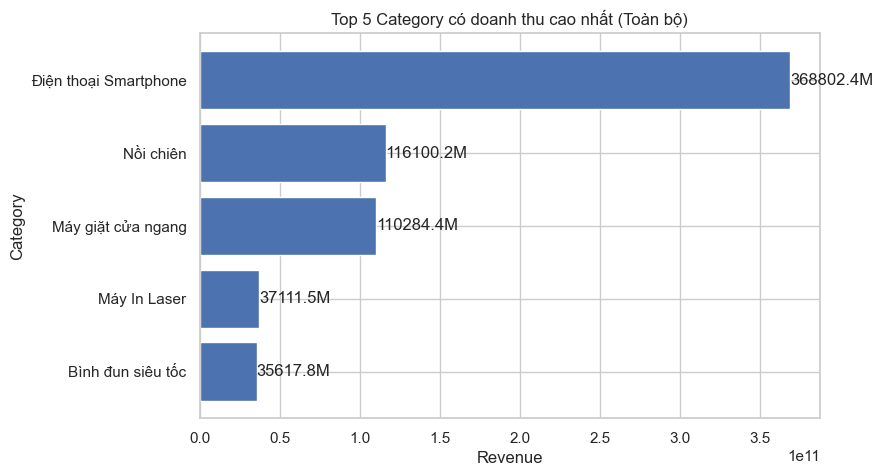

In [9]:
plt.figure(figsize=(8,5))

plt.barh(top5_all["category_name"], top5_all["revenue"])
plt.gca().invert_yaxis()

for i, v in enumerate(top5_all["revenue"]):
    plt.text(v, i, f"{v/1e6:.1f}M", va='center')

plt.title("Top 5 Category có doanh thu cao nhất (Toàn bộ)")
plt.xlabel("Revenue")
plt.ylabel("Category")

plt.show()

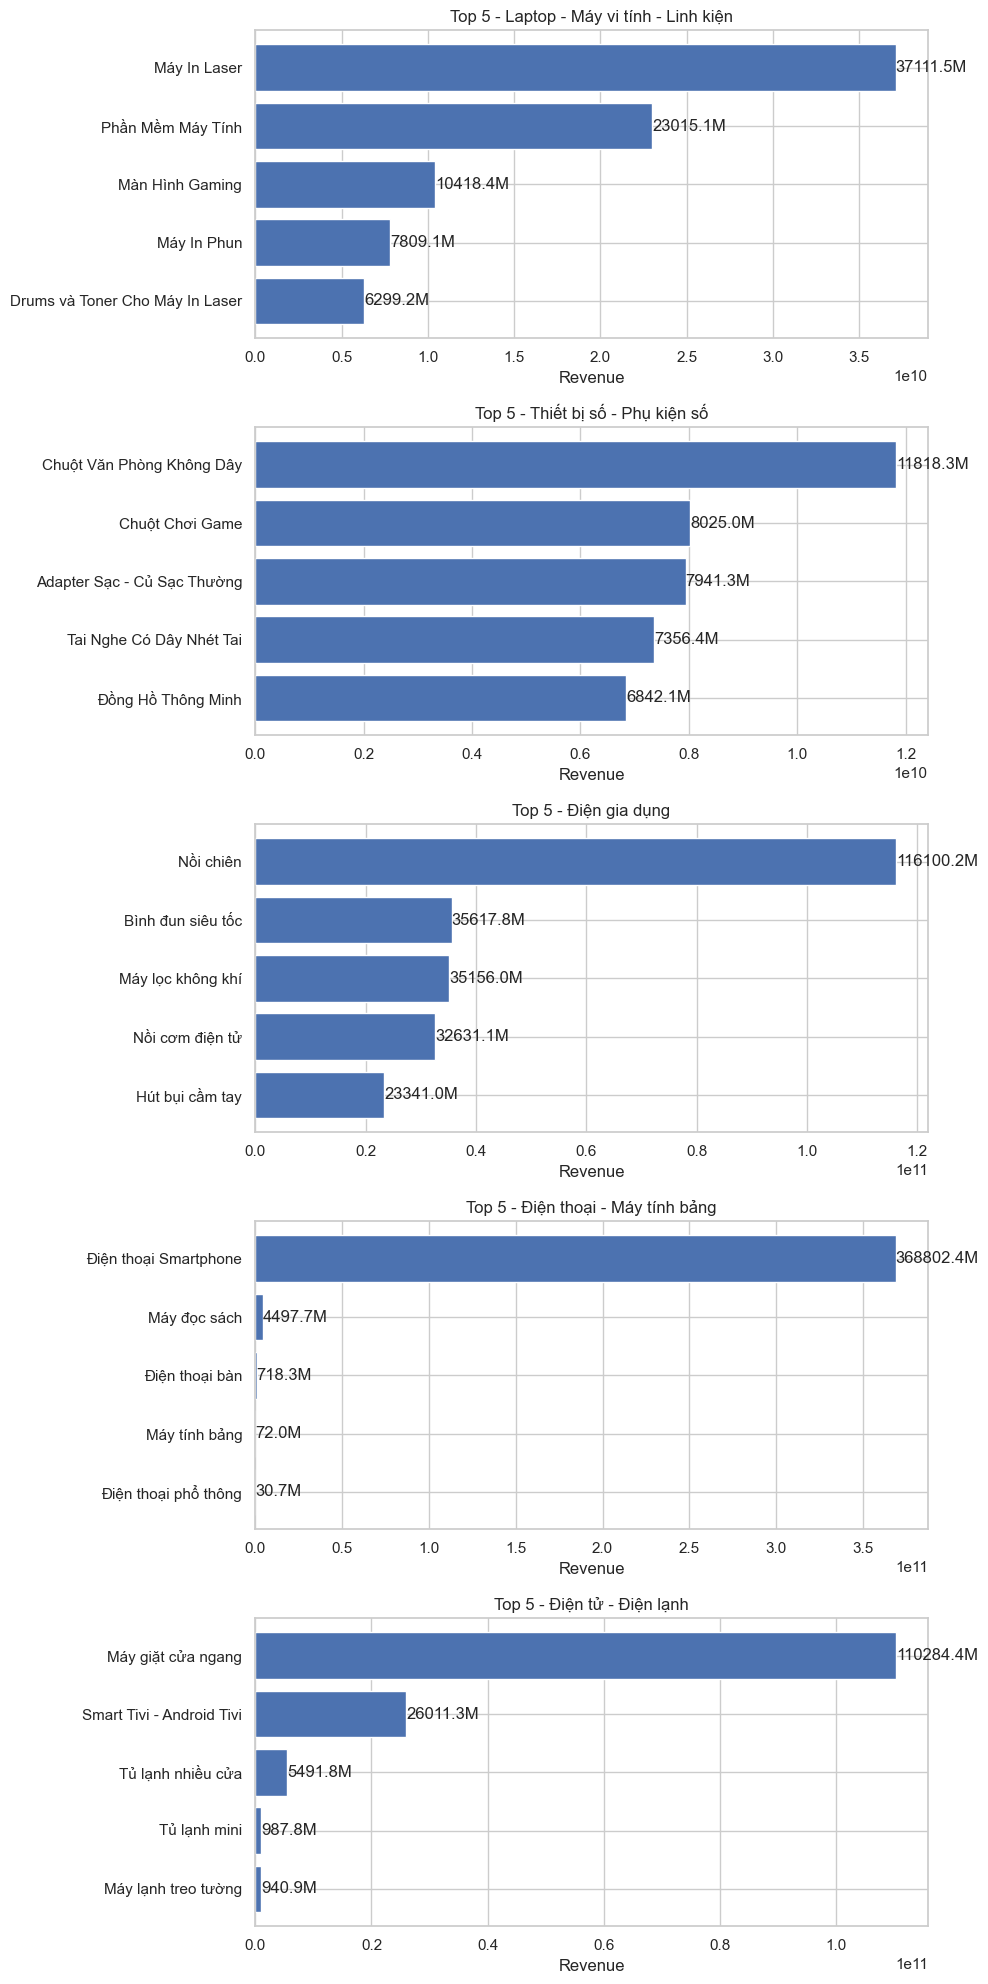

In [10]:
roots = top5_each_root["root_category_name"].unique()
n = len(roots)

fig, axes = plt.subplots(n, 1, figsize=(10, 4*n), squeeze=False)
axes = axes.flatten()

for i, root in enumerate(roots):
    data = top5_each_root[top5_each_root["root_category_name"] == root]
    
    axes[i].barh(data["category_name"], data["revenue"])
    axes[i].invert_yaxis()
    
    for j, v in enumerate(data["revenue"]):
        axes[i].text(v, j, f"{v/1e6:.1f}M", va='center')
    
    axes[i].set_title(f"Top 5 - {root}")
    axes[i].set_xlabel("Revenue")

plt.tight_layout()
plt.show()

### Analysis and Conclusion - Question 1

#### Key Observations:

1. 
2. 
3. 
#### Conclusion:


## 4. Question 2: 

Methodological Notes:

- Revenue is approximated as price × sold_count, acknowledging potential measurement noise (e.g., missing discounts).
- Only features available at or before the point of sale are considered in the main modeling phase to reduce data leakage risk.
- Review-based features are analyzed separately as post-purchase signals to understand customer engagement patterns rather than as predictive drivers.
- XGBoost is used to capture non-linear relationships and interactions between variables.
- Feature importance is interpreted as contribution to prediction, not causal effect.

In [19]:
df_q2_product = df_q1_product.copy()
df_q2_category = df_q1_category.copy()
df_q2_store = df_store.copy()
df_q2_review = df_review.copy()

In [20]:
df_review_agg = (
    df_q2_review
    .groupby("product_id")
    .agg({
        "rating": ["mean", "count"],
        "like_count": "mean"
    })
)

df_review_agg.columns = ["review_rating_avg", "review_count", "review_like_avg"]
df_review_agg = df_review_agg.reset_index()

In [21]:
df = df_q2_product.merge(
    df_review_agg, on="product_id", how="left", suffixes=("", "_drop")
)
df = df.merge(df_q2_store, on="store_id", how="left", suffixes=("", "_drop2"))
df = df[[c for c in df.columns if not c.endswith(("_drop", "_drop2"))]]

In [22]:
df.fillna({
    "review_rating_avg": 0,
    "review_count": 0,
    "review_like_avg": 0,
    "store_rating": 0,
    "follower_count": 0
}, inplace=True)

In [23]:
features = [
    "price",
    "discount_percent",
    "rating_avg",          # product rating
    "review_rating_avg",   # review signal
    "review_count",
    "review_like_avg",
    "store_rating",
    "follower_count"
]

target = "revenue"

In [25]:
from xgboost import XGBRegressor

X = df[features]
y = df["revenue"]

model_all = XGBRegressor(n_estimators=200, random_state=42)
model_all.fit(X, y)

importance_all = pd.Series(model_all.feature_importances_, index=features) \
                    .sort_values(ascending=False)

print("=== FEATURE IMPORTANCE (ALL) ===")
print(importance_all)

=== FEATURE IMPORTANCE (ALL) ===
rating_avg           0.267534
review_count         0.237165
price                0.190788
review_like_avg      0.185378
review_rating_avg    0.048895
follower_count       0.044272
discount_percent     0.024408
store_rating         0.001559
dtype: float32


In [27]:
importance_root = {}

for root in df["root_category_name"].unique():
    df_sub = df[df["root_category_name"] == root]
    
    if len(df_sub) < 50:
        continue
    
    X = df_sub[features]
    y = df_sub["revenue"]
    
    model = XGBRegressor(n_estimators=200, random_state=42)
    model.fit(X, y)
    
    importance_root[root] = pd.Series(
        model.feature_importances_, index=features
    ).sort_values(ascending=False)

print("\n=== FEATURE IMPORTANCE THEO ROOT CATEGORY ===")
for root, imp in importance_root.items():
    print(f"\n--- {root} ---")
    print(imp)


=== FEATURE IMPORTANCE THEO ROOT CATEGORY ===

--- Điện gia dụng ---
review_count         0.924065
review_rating_avg    0.056870
price                0.012589
review_like_avg      0.003161
discount_percent     0.001611
rating_avg           0.001364
follower_count       0.000253
store_rating         0.000086
dtype: float32

--- Điện tử - Điện lạnh ---
review_count         0.748924
follower_count       0.245033
price                0.003546
discount_percent     0.002402
review_like_avg      0.000061
rating_avg           0.000019
store_rating         0.000009
review_rating_avg    0.000005
dtype: float32

--- Điện thoại - Máy tính bảng ---
review_count         6.220105e-01
review_rating_avg    1.672985e-01
discount_percent     7.550790e-02
price                7.339662e-02
review_like_avg      3.540340e-02
rating_avg           2.630748e-02
follower_count       7.467511e-05
store_rating         9.679745e-07
dtype: float32

--- Thiết bị số - Phụ kiện số ---
review_count         0.659704
pri

In [28]:
importance_top_cat = {}

for root in df["root_category_name"].unique():
    top_cats = top5_each_root[
        top5_each_root["root_category_name"] == root
    ]["category_name"].unique()
    
    for cat in top_cats:
        df_sub = df[
            (df["root_category_name"] == root) &
            (df["category_name"] == cat)
        ]
        
        if len(df_sub) < 30:
            continue
        
        X = df_sub[features]
        y = df_sub["revenue"]
        
        model = XGBRegressor(n_estimators=200, random_state=42)
        model.fit(X, y)
        
        importance_top_cat[(root, cat)] = pd.Series(
            model.feature_importances_, index=features
        ).sort_values(ascending=False)

print("\n=== FEATURE IMPORTANCE THEO TOP CATEGORY ===")
for (root, cat), imp in importance_top_cat.items():
    print(f"\n--- {root} > {cat} ---")
    print(imp)


=== FEATURE IMPORTANCE THEO TOP CATEGORY ===

--- Điện gia dụng > Nồi chiên ---
review_count         9.995300e-01
review_rating_avg    4.442630e-04
review_like_avg      1.328840e-05
discount_percent     7.808922e-06
price                3.289206e-06
follower_count       6.686766e-07
rating_avg           5.905004e-07
store_rating         1.982836e-07
dtype: float32

--- Điện gia dụng > Bình đun siêu tốc ---
review_count         0.998835
price                0.000810
review_like_avg      0.000329
discount_percent     0.000017
follower_count       0.000004
review_rating_avg    0.000002
rating_avg           0.000002
store_rating         0.000001
dtype: float32

--- Điện gia dụng > Máy lọc không khí ---
review_count         0.998748
price                0.000663
discount_percent     0.000440
review_like_avg      0.000086
rating_avg           0.000039
store_rating         0.000015
review_rating_avg    0.000008
follower_count       0.000002
dtype: float32

--- Điện gia dụng > Nồi cơm điện tử

In [29]:
df_importance_root = pd.DataFrame(importance_root).T
df_importance_all = importance_all.to_frame(name="ALL")

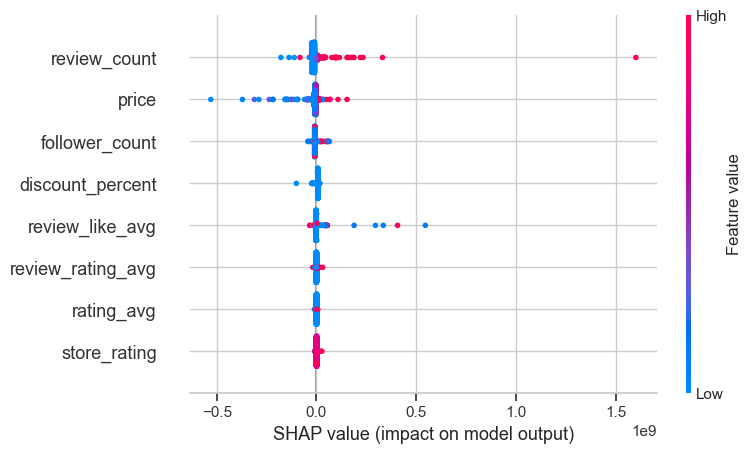

In [32]:
import shap

explainer = shap.Explainer(model_all)
shap_values = explainer(X)

shap.summary_plot(shap_values, X)

### Analysis and Conclusion - Question 2

#### Key Observations:

1. 
2. 
3. 

#### Conclusion:


---
## OVERALL CONCLUSION
